- Entrada: `data/processed/capacitaciones_limpio.csv` y `data/processed/roles_columnas.json` (salida de `02_preprocesamiento.ipynb`).
- Salida: `data/processed/train.csv` (con columna `FOLD`), `data/processed/test.csv`, `split_ediciones.csv` y `split_config.json`.
- Aquí se **separan** los datos y se fijan las referencias para evaluar (qué errores importan y qué resultado logra un modelo trivial). No se ajusta ninguna transformación ni modelo real: eso ocurre después, solo con `train`.

## 1. Importar herramientas

In [14]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.dummy import DummyClassifier
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, f1_score, make_scorer, precision_score, recall_score
from sklearn.model_selection import StratifiedGroupKFold, cross_val_predict, cross_validate, train_test_split

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 70)

RANDOM_STATE = 42
GUARDAR_FIGURAS = True   # guarda las figuras en reports/figures/ para la presentación

## 2. Cargar el dataset limpio

Se lee la salida del preprocesamiento y se comprueba que coincida con lo que se dejó documentado (36 681 registros, 198 ediciones, riesgo ~5.9 %).

In [15]:
def encontrar_raiz():
    p = Path.cwd().resolve()
    for c in [p, *p.parents]:
        if (c / "data").is_dir() and (c / "src").is_dir():
            return c
    raise FileNotFoundError("No se encontró la raíz del proyecto (carpetas data/ y src/).")


ROOT = encontrar_raiz()
CARPETA_PROCESADOS = ROOT / "data" / "processed"
CARPETA_FIGURAS = ROOT / "reports" / "figures"
RUTA = CARPETA_PROCESADOS / "capacitaciones_limpio.csv"
if not RUTA.exists():
    raise FileNotFoundError(f"No existe {RUTA}\nEjecuta primero: notebooks/02_preprocesamiento.ipynb")

ROLES = json.loads((CARPETA_PROCESADOS / "roles_columnas.json").read_text(encoding="utf-8"))
df = pd.read_csv(RUTA, encoding="utf-8-sig", parse_dates=["INICIO", "TERMINO"])

faltan = [c for grupo in ROLES.values() for c in grupo if c not in df.columns]
assert not faltan, f"Columnas de roles_columnas.json que no están en el CSV: {faltan}"

print(f"Dimensiones: {df.shape} · ediciones: {df['EDICION'].nunique()} · "
      f"casos de riesgo: {int(df['y'].sum()):,} ({df['y'].mean():.2%})")
df.head()

Dimensiones: (36681, 22) · ediciones: 198 · casos de riesgo: 2,170 (5.92%)


,EDICION,y,ESTADO_CAPACITACION,DEPARTAMENTO,SEXO,NIVEL_GOBIERNO,TRABAJA_ENTIDAD_PUBLICA,TIPO_CAPACITACION,MODALIDAD,TIPO_CONVOCATORIA,HORAS_ACADEMICAS,MES_INICIO,ANIO_INICIO,DURACION_DIAS,NOMBRE_CAPACITACION,PROVINCIA,DISTRITO,INICIO,TERMINO,FECHA_TERMINO_CORREGIDA,HORAS_ATIPICA,DURACION_ATIPICA
0,GESTIÓN PÚBLICA CON ENFOQUE DE GÉNERO | 20250904 | 20250925 | REMOTA,1,DESAPROBADO,LORETO,HOMBRE,NACIONAL,SI,CURSO,REMOTA,CONCURSO PÚBLICO,28.0,9,2025,21,GESTIÓN PÚBLICA CON ENFOQUE DE GÉNERO,MAYNAS,SAN JUAN BAUTISTA,2025-09-04,2025-09-25,False,True,False
1,GESTIÓN PÚBLICA CON ENFOQUE DE GÉNERO | 20250904 | 20250925 | REMOTA,0,APROBADO,CALLAO,MUJER,REGIONAL,SI,CURSO,REMOTA,CONCURSO PÚBLICO,28.0,9,2025,21,GESTIÓN PÚBLICA CON ENFOQUE DE GÉNERO,CALLAO,CALLAO,2025-09-04,2025-09-25,False,True,False
2,GESTIÓN PÚBLICA CON ENFOQUE DE GÉNERO | 20250904 | 20250925 | REMOTA,0,APROBADO,PIURA,MUJER,LOCAL,SI,CURSO,REMOTA,CONCURSO PÚBLICO,28.0,9,2025,21,GESTIÓN PÚBLICA CON ENFOQUE DE GÉNERO,AYABACA,LAGUNAS,2025-09-04,2025-09-25,False,True,False
3,GESTIÓN PÚBLICA CON ENFOQUE DE GÉNERO | 20250904 | 20250925 | REMOTA,0,APROBADO,LIMA,MUJER,NACIONAL,SI,CURSO,REMOTA,CONCURSO PÚBLICO,28.0,9,2025,21,GESTIÓN PÚBLICA CON ENFOQUE DE GÉNERO,LIMA,JESÚS MARÍA,2025-09-04,2025-09-25,False,True,False
4,GESTIÓN PÚBLICA CON ENFOQUE DE GÉNERO | 20250904 | 20250925 | REMOTA,0,APROBADO,AYACUCHO,MUJER,REGIONAL,SI,CURSO,REMOTA,CONCURSO PÚBLICO,28.0,9,2025,21,GESTIÓN PÚBLICA CON ENFOQUE DE GÉNERO,HUAMANGA,AYACUCHO,2025-09-04,2025-09-25,False,True,False


## 3. Qué hay que decidir y parámetros

| # | Decisión | Qué se hace | Dónde |
|---|---|---|---|
| 1 | ¿Se separa al azar o por grupos? | Por **edición**: una edición completa va a un solo conjunto | Bloque 1 |
| 2 | ¿Qué proporciones? | **80 % train / 20 % test**; la validación sale de dividir `train` en 5 partes | Bloque 2 |
| 3 | ¿Cómo mantener el 5.9 % de riesgo en cada parte? | Separación estratificada por `y` y por grupos a la vez | Bloque 2 |
| 4 | ¿Cómo se evita la fuga de información? | Separar antes de ajustar nada, test intacto, comprobaciones automáticas | Bloque 3 |

In [16]:
PROP_TEST = 0.20        # parte reservada para la prueba final
N_FOLDS = 5             # partes de train para validación cruzada
N_INTENTOS = 50         # particiones candidatas para el test
GRUPO = ROLES["agrupacion"][0]          # "EDICION"
PREDICTORAS = ROLES["predictoras_candidatas"]
NO_USAR = ROLES["origen_objetivo_no_usar_como_predictora"] + ROLES["revisar_fuga"] + [GRUPO]


def guardar(nombre):
    if GUARDAR_FIGURAS:
        CARPETA_FIGURAS.mkdir(parents=True, exist_ok=True)
        plt.savefig(CARPETA_FIGURAS / f"{nombre}.png", bbox_inches="tight", dpi=150)


def resumen(d):
    # una fila de resumen para un conjunto de registros
    return pd.Series({
        "registros": len(d),
        "ediciones": d[GRUPO].nunique(),
        "casos_riesgo": int(d["y"].sum()),
        "riesgo_%": round(d["y"].mean() * 100, 2),
        "retirados": int((d["ESTADO_CAPACITACION"] == "RETIRADO").sum()),
    })

# BLOQUE 1 - ¿POR QUÉ SEPARAR POR EDICIÓN?

## 4. ¿Qué pasa si se separa al azar?

Pregunta: **¿una separación al azar por filas sería lo ideal?**

El EDA mostró que la edición explica buena parte del resultado (~14 %) y que unas pocas ediciones concentran el riesgo. Además, el 58 % de las filas son idénticas entre sí (la identidad está enmascarada). Se mide qué tan parecidos quedarían train y test con una separación al azar y se compara con la separación por edición que se usará.

- `% de test con su edición en train`: ¿el modelo ya vio ese curso al entrenar?
- `% de test con una fila idéntica en train`: ¿ya vio una fila exactamente igual (mismo perfil y misma edición)?

In [17]:
def solapamiento(df, idx_tr, idx_te):
    tr, te = df.iloc[idx_tr], df.iloc[idx_te]
    misma_edicion = te[GRUPO].isin(set(tr[GRUPO])).mean()
    clave = PREDICTORAS + [GRUPO]
    m = te[clave].merge(tr[clave].drop_duplicates(), how="left", on=clave, indicator=True)
    return {"% de test con su edición en train": round(misma_edicion * 100, 1),
            "% de test con una fila idéntica en train": round((m["_merge"] == "both").mean() * 100, 1)}


# A) al azar por filas (solo para comparar, NO se usa)
idx_tr_azar, idx_te_azar = train_test_split(np.arange(len(df)), test_size=PROP_TEST,
                                            stratify=df["y"], random_state=RANDOM_STATE)

# B) por edición (la que se usará), aquí una versión de prueba, la definitiva se elige en la sección 5
sgkf = StratifiedGroupKFold(n_splits=round(1 / PROP_TEST), shuffle=True, random_state=RANDOM_STATE)
idx_tr_grupo, idx_te_grupo = next(sgkf.split(df, df["y"], groups=df[GRUPO]))

comparacion = pd.DataFrame({"Al azar por filas": solapamiento(df, idx_tr_azar, idx_te_azar),
                            "Por edición": solapamiento(df, idx_tr_grupo, idx_te_grupo)})
display(comparacion)

,Al azar por filas,Por edición
% de test con su edición en train,100.0,0.0
% de test con una fila idéntica en train,82.0,0.0


Con la separación al azar, casi todo el test tiene su edición en train y una buena parte de sus filas tiene una gemela exacta del otro lado. El modelo podría acertar **recordando el curso**, no aprendiendo qué hace riesgoso a un curso. Las métricas saldrían más bonitas de lo que son.

Separando por edición, ninguna edición aparece en los dos lados. La prueba responde mejor la pregunta real: ¿funciona con una capacitación que el modelo no vio?

**Decisión:** separar siempre por `EDICION`.

# BLOQUE 2 - SEPARACIÓN

## 5. Reservar el test (20 %)

Pregunta: **¿qué ediciones quedan como prueba final?**

Con solo 198 ediciones, y unas pocas muy grandes (la mayor tiene más de 2 mil personas), una partición cualquiera puede dejar un test demasiado grande, chico o con otro riesgo. Se generan 50 particiones candidatas (estratificadas por `y` y agrupadas por edición) y se elige la que mejor conserve: el 20 % de los registros, el riesgo global y la mezcla de tipos de capacitación.

La elección usa **solo proporciones de los datos**, nunca el resultado de un modelo, así que no introduce fuga.

In [18]:
def particion_test(semilla):
    sgkf = StratifiedGroupKFold(n_splits=round(1 / PROP_TEST), shuffle=True, random_state=semilla)
    return next(sgkf.split(df, df["y"], groups=df[GRUPO]))


def desvio(idx_te):
    # 0 = el test es una copia en miniatura del total
    te = df.iloc[idx_te]
    d_tam = abs(len(te) / len(df) - PROP_TEST) / PROP_TEST
    d_riesgo = abs(te["y"].mean() - df["y"].mean()) / df["y"].mean()
    p_total = df["TIPO_CAPACITACION"].value_counts(normalize=True)
    p_test = te["TIPO_CAPACITACION"].value_counts(normalize=True).reindex(p_total.index, fill_value=0)
    d_tipo = 0.5 * (p_total - p_test).abs().sum()
    return d_tam + d_riesgo + d_tipo


candidatas = []
for semilla in range(N_INTENTOS):
    idx_tr, idx_te = particion_test(semilla)
    te = df.iloc[idx_te]
    candidatas.append({"semilla": semilla, "%_registros": round(len(te) / len(df) * 100, 1),
                       "riesgo_%": round(te["y"].mean() * 100, 2), "ediciones": te[GRUPO].nunique(),
                       "desvío": round(desvio(idx_te), 3)})
candidatas = pd.DataFrame(candidatas).sort_values("desvío").reset_index(drop=True)
display(candidatas.head(5))

SEMILLA_TEST = int(candidatas.loc[0, "semilla"])
idx_train, idx_test = particion_test(SEMILLA_TEST)
train = df.iloc[idx_train].reset_index(drop=True)
test = df.iloc[idx_test].reset_index(drop=True)
print(f"Semilla elegida: {SEMILLA_TEST} · train: {len(train):,} registros · test: {len(test):,} registros")

,semilla,%_registros,riesgo_%,ediciones,desvío
0,34,20.0,5.92,40,0.222
1,5,20.0,5.92,42,0.225
2,6,20.1,6.00,42,0.226
3,2,20.1,5.98,39,0.227
4,20,20.2,5.94,39,0.230


Semilla elegida: 34 · train: 29,336 registros · test: 7,345 registros


La tabla muestra las 5 mejores particiones (menor desvío). Se elige la primera. Desde aquí `test` **no se vuelve a tocar** hasta la evaluación final, no sirve para ajustar umbrales, elegir variables ni comparar modelos.

## 6. Validación dentro de train

Pregunta: **¿cómo se comparan modelos sin usar el test?**

Se divide `train` en 5 partes por edición, también estratificadas por `y`. Cada parte sirve una vez como validación y las otras 4 como entrenamiento.

Equivalencia con el esquema train / validation / test:

| Rol | Qué es aquí | % del total |
|---|---|---|
| Train | Cuatro de las cinco partes de `train` (en cada vuelta) | ~64 % |
| Validation | La parte restante (rota en cada vuelta) | ~16 % |
| Test | Reservado, se usa una sola vez al final | 20 % |

Se decide aplicar una validación cruzada por grupos en vez de un único conjunto de validación fijo (por ejemplo 70/15/15). Con 198 ediciones y solo 110 retirados, un conjunto fijo de ~16 % quedaría con muy pocos casos de riesgo y con unas pocas ediciones mandando; el resultado dependería de la suerte. Con 5 partes se usan todos los datos de `train` y se obtiene un promedio **y** cuánto varía la métrica entre partes.

In [19]:
sgkf = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
fold = np.full(len(train), -1)
for k, (_, idx_val) in enumerate(sgkf.split(train, train["y"], groups=train[GRUPO])):
    fold[idx_val] = k
train["FOLD"] = fold

assert (train["FOLD"] >= 0).all(), "Hay registros sin parte asignada"
print("Partes de validación:", N_FOLDS, "| registros por parte:", train["FOLD"].value_counts().sort_index().to_dict())

Partes de validación: 5 | registros por parte: {0: 5851, 1: 5891, 2: 5784, 3: 5930, 4: 5880}


## 7. Resumen de los conjuntos

Pregunta: **¿cuánto quedó en cada conjunto y se parecen entre sí?**

,registros,registros_%,ediciones,casos_riesgo,riesgo_%,retirados
Train (total),29336,80.0,158,1735,5.91,76
validación parte 0,5851,16.0,31,342,5.85,22
validación parte 1,5891,16.1,31,346,5.87,15
validación parte 2,5784,15.8,30,359,6.21,4
validación parte 3,5930,16.2,34,354,5.97,27
validación parte 4,5880,16.0,32,334,5.68,8
Test,7345,20.0,40,435,5.92,34
TOTAL,36681,100.0,198,2170,5.92,110


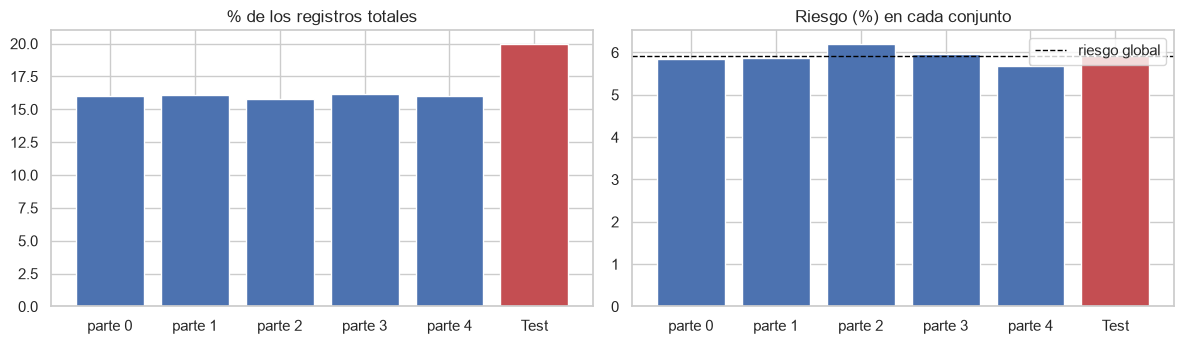

In [20]:
filas = {"Train (total)": resumen(train)}
for k in range(N_FOLDS):
    filas[f"  validación parte {k}"] = resumen(train[train["FOLD"] == k])
filas["Test"] = resumen(test)
filas["TOTAL"] = resumen(df)

tabla = pd.DataFrame(filas).T
tabla["registros_%"] = (tabla["registros"] / len(df) * 100).round(1)
tabla = tabla[["registros", "registros_%", "ediciones", "casos_riesgo", "riesgo_%", "retirados"]]
tabla[["registros", "ediciones", "casos_riesgo", "retirados"]] = tabla[["registros", "ediciones", "casos_riesgo", "retirados"]].astype(int)
display(tabla)

nombres = [f"parte {k}" for k in range(N_FOLDS)] + ["Test"]
reg_pct = [tabla.loc[f"  validación parte {k}", "registros_%"] for k in range(N_FOLDS)] + [tabla.loc["Test", "registros_%"]]
riesgo = [tabla.loc[f"  validación parte {k}", "riesgo_%"] for k in range(N_FOLDS)] + [tabla.loc["Test", "riesgo_%"]]
colores = ["#4C72B0"] * N_FOLDS + ["#C44E52"]

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
axes[0].bar(nombres, reg_pct, color=colores)
axes[0].set_title("% de los registros totales")
axes[1].bar(nombres, riesgo, color=colores)
axes[1].axhline(df["y"].mean() * 100, color="black", ls="--", lw=1, label="riesgo global")
axes[1].set_title("Riesgo (%) en cada conjunto")
axes[1].legend()
plt.tight_layout()
guardar("13_particion_conjuntos")
plt.show()

Cada parte de validación queda cerca del 16 % de los registros y el test cerca del 20 %. El riesgo se mantiene cerca del promedio (línea punteada), con algo de variación porque se separa por ediciones enteras y no por filas sueltas.

Los **retirados** son pocos (110 en total, y menos aún en cada conjunto). Cuentan dentro del grupo de riesgo, pero no alcanzan para evaluarlos por separado.

## 8. ¿Se parecen train y test?

Pregunta: **¿el test representa los mismos tipos de capacitación y participantes que train?**

Si el test fuera muy distinto (por ejemplo, sin talleres), la métrica final no diría nada del conjunto completo.

In [21]:
conjunto = pd.concat([train.assign(CONJUNTO="train"), test.assign(CONJUNTO="test")], ignore_index=True)

for c in ["TIPO_CAPACITACION", "NIVEL_GOBIERNO", "SEXO"]:
    comp = pd.crosstab(conjunto[c], conjunto["CONJUNTO"], normalize="columns").mul(100).round(1)
    comp["riesgo_train_%"] = conjunto[conjunto["CONJUNTO"] == "train"].groupby(c)["y"].mean().mul(100).round(1)
    comp["riesgo_test_%"] = conjunto[conjunto["CONJUNTO"] == "test"].groupby(c)["y"].mean().mul(100).round(1)
    display(comp.rename(columns={"train": "train_%", "test": "test_%"}))

print("Las 5 ediciones más grandes y dónde quedaron:")
grandes = (df.groupby(GRUPO).agg(registros=("y", "size"), riesgo=("y", "mean")).sort_values("registros", ascending=False).head(5))
grandes["conjunto"] = grandes.index.map(conjunto.drop_duplicates(GRUPO).set_index(GRUPO)["CONJUNTO"])
grandes["riesgo"] = (grandes["riesgo"] * 100).round(1)
display(grandes.rename(columns={"riesgo": "riesgo_%"}))

CONJUNTO,test_%,train_%,riesgo_train_%,riesgo_test_%
TIPO_CAPACITACION,,,,
CURSO,31.7,5.5,5.8,0.6
CURSO MOOC,53.2,62.8,5.4,5.7
INNOVATHON,0.0,0.2,12.5,NaN
MICROCURSO,2.6,2.9,14.2,4.7
PROGRAMA,1.7,19.1,2.4,42.7
TALLER,10.8,9.5,13.6,17.1


CONJUNTO,test_%,train_%,riesgo_train_%,riesgo_test_%
NIVEL_GOBIERNO,,,,
LOCAL,13.4,14.8,8.8,9.3
NACIONAL,71.3,70.4,4.9,4.8
"NO APLICA (PRIVADO, UNIVERSITARIO, LOCADOR, ETC)",4.3,4.8,9.4,12.7
ORGANISMOS AUTÓNOMOS,3.7,2.9,3.4,3.0
REGIONAL,7.4,7.2,8.8,7.8


CONJUNTO,test_%,train_%,riesgo_train_%,riesgo_test_%
SEXO,,,,
HOMBRE,51.3,52.6,5.9,5.9
MUJER,48.7,47.4,5.9,6.0


Las 5 ediciones más grandes y dónde quedaron:


,registros,riesgo_%,conjunto
EDICION,,,
"NORMAS, TRANSPARENCIA Y LIDERAZGO ÉTICO PARA LA LUCHA CONTRA LA CORRUPCIÓN EN EL PERÚ | 20251006 | 20251209 | E-LEARNING_CONVENCIONAL",2291,0.3,test
PROGRAMA DE CAPACITACIÓN EN INTEGRIDAD PÚBLICA Y LUCHA CONTRA LA CORRUPCIÓN - 2025 | 20250407 | 20251209 | E-LEARNING_CONVENCIONAL,2034,0.0,train
ESTRATEGIAS ANTICORRUPCIÓN PARA FORTALECER LA INTEGRIDAD PÚBLICA | 20250707 | 20250930 | E-LEARNING,1750,1.1,train
MODERNIZACIÓN DE LA GESTIÓN PÚBLICA | 20250217 | 20251130 | E-LEARNING_MOOC,1583,0.0,train
ÉTICA E INTEGRIDAD PÚBLICA PARA LA PREVENCIÓN DE LA CORRUPCIÓN | 20250407 | 20151201 | E-LEARNING,1498,1.7,train


# BLOQUE 3 - VERIFICACIÓN Y GUARDADO

## 9. Medidas contra la fuga de información

Pregunta: **¿qué evita que la prueba se contamine?**

| Medida | Cómo se cumple |
|---|---|
| Separar antes de ajustar nada | Este notebook no calcula medias, categorías ni codificaciones |
| Ninguna edición en dos conjuntos | Separación por `EDICION` (se comprueba abajo) |
| Test intacto | Se guarda aparte y no se usa para elegir modelo, variables ni umbral |
| Transformaciones solo con train | En el `Pipeline` se ajustan dentro de cada parte de entrenamiento, nunca con la validación ni el test |
| Sin variables que filtren el resultado | `ESTADO_CAPACITACION`, `EDICION` y `DURACION_DIAS` quedan fuera de las predictoras |
| Sin datos agregados de la edición | No se usa el tamaño ni el riesgo de la edición como variable |
| Elección de la semilla sin modelos | Solo se compararon proporciones |

In [ ]:
ed_train, ed_test = set(train[GRUPO]), set(test[GRUPO])
ed_por_parte = [set(train.loc[train["FOLD"] == k, GRUPO]) for k in range(N_FOLDS)]
parejas_partes = [(i, j) for i in range(N_FOLDS) for j in range(i + 1, N_FOLDS)]

checks = pd.Series({
    "train + test = total de registros": len(train) + len(test) == len(df),
    "ninguna edición en train y test": ed_train.isdisjoint(ed_test),
    "todas las ediciones quedaron asignadas": (ed_train | ed_test) == set(df[GRUPO]),
    "ninguna edición en dos partes de validación": all(ed_por_parte[i].isdisjoint(ed_por_parte[j]) for i, j in parejas_partes),
    "cada parte de validación tiene casos de riesgo": all(train.loc[train["FOLD"] == k, "y"].sum() > 0 for k in range(N_FOLDS)),
    "el test tiene casos de riesgo": test["y"].sum() > 0,
    "predictoras sin ESTADO / EDICION / DURACION_DIAS": not set(PREDICTORAS) & set(NO_USAR),
    "ninguna predictora tiene vacíos": not df[PREDICTORAS].isna().any().any(),
}, name="cumple")
display(checks.to_frame())
assert checks.all(), "Alguna comprobación de la separación falla"

# ediciones distintas pero del mismo curso (mismo nombre) que quedaron en lados opuestos
nombre_ed = df.drop_duplicates(GRUPO).set_index(GRUPO)["NOMBRE_CAPACITACION"]
n_repetidos = nombre_ed.map(nombre_ed.value_counts()).gt(1).sum()
cursos_cruzados = set(test["NOMBRE_CAPACITACION"]) & set(train["NOMBRE_CAPACITACION"])
print(f"Ediciones cuyo curso tiene más de una edición: {n_repetidos} de {len(nombre_ed)} | "
      f"cursos con ediciones en train y en test: {len(cursos_cruzados)}")

,cumple
train + test = total de registros,True
ninguna edición en train y test,True
todas las ediciones quedaron asignadas,True
ninguna edición en dos partes de validación,True
cada parte de validación tiene casos de riesgo,True
el test tiene casos de riesgo,True
predictoras sin ESTADO / EDICION / DURACION_DIAS,True
ninguna predictora tiene vacíos,True


Ediciones cuyo curso tiene más de una edición: 163 de 198 · cursos con ediciones en train y en test: 17


Todas las comprobaciones deben dar `True`, si alguna falla, el notebook se detiene.

La última línea mide una limitación: si un mismo curso tuvo varias ediciones, algunas pueden quedar en train y otras en test. Son ediciones distintas, pero se parecen.

## 10. Guardar

Se guardan los conjuntos, la lista de ediciones con su conjunto y los parámetros usados, para que cualquiera obtenga **exactamente** la misma separación. `test.csv` no se abre hasta la evaluación final.

In [22]:
CARPETA_PROCESADOS.mkdir(parents=True, exist_ok=True)
train.to_csv(CARPETA_PROCESADOS / "train.csv", index=False, encoding="utf-8-sig")
test.to_csv(CARPETA_PROCESADOS / "test.csv", index=False, encoding="utf-8-sig")

mapa = pd.concat([train.groupby(GRUPO)["FOLD"].first().rename("FOLD"),
                  pd.Series(-1, index=sorted(ed_test), name="FOLD")])
split_ediciones = (mapa.rename_axis(GRUPO).reset_index()
                   .assign(CONJUNTO=lambda d: np.where(d["FOLD"] >= 0, "train", "test"))
                   [[GRUPO, "CONJUNTO", "FOLD"]].sort_values(GRUPO))
split_ediciones.to_csv(CARPETA_PROCESADOS / "split_ediciones.csv", index=False, encoding="utf-8-sig")

CONFIG = {
    "agrupacion": GRUPO,
    "estratificacion": "y",
    "prop_test": PROP_TEST,
    "n_folds": N_FOLDS,
    "random_state_folds": RANDOM_STATE,
    "semilla_test": SEMILLA_TEST,
    "n_intentos_semilla": N_INTENTOS,
    "registros": {"train": len(train), "test": len(test)},
    "ediciones": {"train": len(ed_train), "test": len(ed_test)},
    "riesgo_%": {"train": round(train["y"].mean() * 100, 2), "test": round(test["y"].mean() * 100, 2)},
    "predictoras": PREDICTORAS,
}
(CARPETA_PROCESADOS / "split_config.json").write_text(json.dumps(CONFIG, ensure_ascii=False, indent=2), encoding="utf-8")
print("Guardado en", CARPETA_PROCESADOS.relative_to(ROOT), "-> train.csv, test.csv, split_ediciones.csv, split_config.json")

Guardado en data\processed -> train.csv, test.csv, split_ediciones.csv, split_config.json
